In [1]:
import numpy as np
import matplotlib.pyplot as plt   

pre_factor = 0.0591
Eh2eV = 27.2114079527
dim = 3
trathure = 1e-4
n_repr = 2

class PsiClassError(Exception):
    def __init__(self, massage = "Undefined"):
        super().__init__(massage)

class DefinitionError(Exception):
    def __init__(self, massage = "Wrong"):
        super().__init__(massage)

def co(option: str) -> int:
    if option == "pH":
        return 0
    if option == "E":
        return 1
    raise DefinitionError()

def convert_coef(GFE_rec, number_of_O, number_of_H, weight, Q=0, log10_of_conc=0, mu_H2O=2.46):
    # GFE_rec - eV, mu_H2O - eV
    GFE_part = GFE_rec/weight
    conc_part = pre_factor*log10_of_conc/weight
    water_part = -mu_H2O*number_of_O/weight
    pre_pH = -pre_factor*(2*number_of_O - number_of_H)/weight
    pre_E = -(2*number_of_O - number_of_H + Q)/weight
    return (GFE_part, conc_part, water_part, pre_pH, pre_E)

def get_grid(pH_grid: list, E_grid: list, option: str) -> list[list[tuple[float, float]],]:
    co(option)
    grid_2d = None
    if option == "pH":
        grid_2d = [*map(
            lambda x: [*map(
                lambda y: (x, y),
                E_grid
            )],
            pH_grid
        )]
    if option == "E":
        grid_2d = [*map(
            lambda y: [*map(
                lambda x: (x, y),
                pH_grid
            )],
            E_grid
        )]
    return grid_2d  

def repack_points(list_of_points: list[tuple[float, float],]) -> tuple[list[float,], list[float,]]:
    x_or_y_values = []
    Psi_values = []
    for point in list_of_points:
        x_or_y_values.append(point[0])
        Psi_values.append(point[1])
    return (x_or_y_values, Psi_values)


class Psi():
    def __init__(self, GFE_part, conc_part, water_part, pre_pH, pre_E, label):
        self.G = GFE_part
        self.c = conc_part
        self.w = water_part
        self.pH = pre_pH
        self.E = pre_E
        self.label = label
    
    def __mul__(self, other):
        if isinstance(other, (int, float)):
            return Psi(
                *[*map(lambda x: other*x, [self.G, self.c, self.w, self.pH, self.E])],
                label=f"{round(other, n_repr)}{self.label}"
                )
        else:
            raise PsiClassError()
    
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __add__(self, other):
        if isinstance(other, Psi):
            return Psi(
                self.G + other.G,
                self.c + other.c,
                self.w + other.w,
                self.pH + other.pH,
                self.E + other.E,
                f"{self.label} + {other.label}"
            )
        else:
            raise PsiClassError()
    
    def get_plane(self) -> callable:
        return lambda pH, E: self.G + self.c + self.w + self.pH*pH + self.E*E

    def __repr__(self):
        return f"{self.label}"#: {round(self.G, n_repr)} + {round(self.c, n_repr)} + {round(self.w, n_repr)} + {round(self.pH, n_repr)}*pH + {round(self.E, n_repr)}*E"



def get_phase_multiplier(list_of_sulfurs):
    def add_sulfur(list_of_basic_phases, x_fact = 1/12):
        data = []
        y = True
        for phase in list_of_basic_phases:
            if "S" in phase.label:
                if "NiS2" in phase.label:
                    x = 0
                    y = False
                else:
                    x = x_fact
            else:
                x = 0
            if y:
                data += [((1/(3-x))*phase + ((2-x)/(3-x))*SulfIon) for SulfIon in list_of_sulfurs]
            else:
                data += [phase]
        return data
    return add_sulfur

def extrapolate(defect: Psi, init: Psi, x: float) -> Psi:
    x_max = 1/12
    ext = (1-x/x_max)*init + x/x_max*defect
    ext.label = defect.label
    return ext

def add_oxygen(phase: Psi, oxygen: Psi, x: float) -> Psi:
    ext = (1/(1+x))*phase + (x/(1+x))*oxygen
    print(ext.label)
    return ext

option = "pH"

def create_PD_dataset(pH_grid, E_grid, Phases) -> dict[int:dict[str:list[tuple[float, float],],],]:

    def find_min(point):
        i_min, psi_min = sorted(
            map(
                lambda pair: (pair[0], pair[1](*point)),
                enumerate(list_of_planes)
                ), 
            key=lambda x: x[1]
            )[0]
        return (i_min, psi_min)

    def update_internal_dict(i_min, psi_min, point, dict_obj):
        key = Phases[i_min].label
        if dict_obj.get(key) is None:
            dict_obj[key] = []
        dict_obj[key].append((point[1-co(option)], psi_min))

    grid_2d = get_grid(pH_grid, E_grid, option)
    
    list_of_planes = [*map(
        lambda Phase: Phase.get_plane(),
        Phases
        )]
    
    dataset = {}

    for grid_1d in grid_2d:
        dataset_slice = {}
        [*map(
            lambda point: update_internal_dict(
                *find_min(point),
                point,
                dict_obj=dataset_slice
                ),
            grid_1d
            )]

        dataset[grid_1d[0][co(option)]] = dataset_slice.copy()
    
    return dataset

def compress_PD_dataset(DS: dict[float:dict[str: list[tuple[float, float],]],]) -> dict[float:dict[str, tuple[float, float],]]:

    def dump(list_obj, key, label):
        data = list_obj.copy()
        DS[key][label] = (data[0][0], data[-1][0])

    [*map(
        lambda key: [*map(
            lambda label: dump(DS[key][label], key, label),
            DS[key].keys()
        )],
        DS.keys()
    )]

    return DS

def represent_PD_dataset(dataset: dict[float:dict[str, tuple[float, float],]]) -> dict[str:list[tuple[float, float],],]:
    DS = {}

    def arrogate(pH, label):
        E_left, E_right = dataset[pH][label]

        if DS.get(label) is None:
            DS[label] = []

        DS[label] += [(pH, E_left), (pH, E_right)]
    
    [*map(
        lambda pH: [*map(
            lambda label: arrogate(pH, label),
            dataset[pH]
        )],
        dataset.keys()
    )]

    return DS

def represent_PD_dataset_to_draw(DS: dict[str:list[tuple[float, float],],]) -> dict[str: tuple[list[float, float], list[float, float]],]:

    for label in DS.keys():
        pHs = []
        Es = []
        for point in DS[label]:
            pHs.append(point[0])
            Es.append(point[1])
        
        DS[label] = (pHs.copy(), Es.copy())
    return DS

def draw_PD_dataset(dataset: dict[str: tuple[list[float, float], list[float, float]],], limits=None, save_png = False) -> None:
    fig, ax = plt.subplots()
    for label in dataset.keys():
        tuple_of_axis = dataset[label]
        ax.plot(
            *tuple_of_axis,
            "-",
            linewidth=1,
            label=f"{label}"
            )
    
    if not(limits is None):
        ax.set(**limits)
    
    ax.legend(fontsize=7)
    if save_png:
        plt.savefig(f'PD.png', dpi=300)
    
    plt.show()


('Ni3+', 0.9693999999999998)
('Ni_s', 0.0)
('Ni2+', -2.4466)
('NiOH+', -2.6791800000000006)
('NiO', -2.9731600000000005)
('Ni(OH)2', -3.0811600000000006)
('Ni(OH)4--', -3.0989200000000006)
('Ni(OH)3-', -3.1143400000000003)
('NiHO2', -3.3537400000000006)
('Ni3O4', -3.506546666666667)
('NiO2', -3.5753200000000005)
('Ni2O3', -3.6122400000000003)



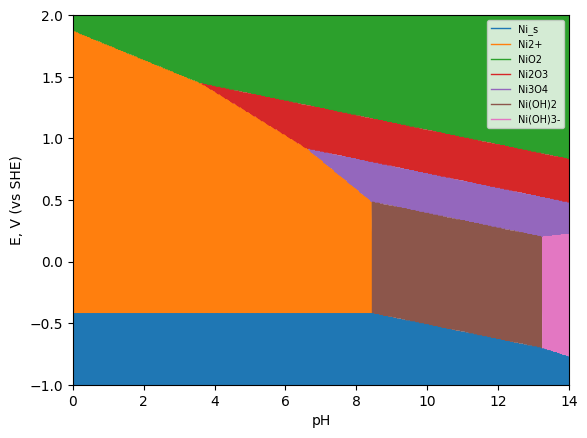

In [2]:
#Ni and water only. Based on bulk experimental thermodynamics
mu_H2O = -2.46
ions = {
    "Ni2+" : (-0.478, 0, 0, 1, 2, -6),
    "Ni3+" : (3.745, 0, 0, 1, 3, -6),
    "NiOH+" : (-2.355, 1, 1, 1, 1, -6),
    "Ni(OH)3-": (-6.079, 3, 3, 1, -1, -6),
    "Ni(OH)4--": (-7.708, 4, 4, 1, -2, -6),
}
solids = {
     "Ni_s" : (0, 0, 0, 1, 0, 0),
    
     "Ni(OH)2":(-4.756, 2, 2, 1, 0, 0),

     "NiO": (-2.188, 1, 0, 1, 0, 0),

     "Ni3O4": (-7.379, 4, 0, 3, 0, 0), 

     "NiHO2":(-3.406, 2, 1, 1, 0, 0),

     "Ni2O3":(-4.869, 3, 0, 2, 0, 0),

     "NiO2":(-2.005, 2, 0, 1, 0, 0),
}
el_phases = {
    **ions,
    **solids
    }

list_of_phases = [Psi(*convert_coef(*el_phases[key], mu_H2O = mu_H2O), label=key) for key in el_phases.keys()] 

Phases = list_of_phases.copy()

for point in [(13.8 ,0.807),]:
    Psis = sorted([(phase.label, phase.get_plane()(*point)) for phase in Phases], key=lambda x: x[1], reverse=True)
    print(*Psis, sep="\n")
    print()


E_min, E_max = -1, 2
pH_min, pH_max = 0, 14
resolution = 400

pH_grid = np.linspace(pH_min, pH_max, resolution)
E_grid = np.linspace(E_min, E_max, resolution)

dataset = represent_PD_dataset_to_draw(
    represent_PD_dataset(
        compress_PD_dataset(
            create_PD_dataset(
                pH_grid,
                E_grid,
                Phases
                )
        )
    )
)

draw_PD_dataset(
    dataset,
    limits = {
    "xlim":(pH_min, pH_max), 
    "xlabel" : "pH", 
    "ylim": (E_min, E_max), 
    "ylabel": f"E, V (vs SHE)"
    },
    save_png=True
    )


('Ni3+', 0.9693999999999998)
('Ni_s', 0.0)
('Ni(OH)4--', -2.368333472669268)
('Ni2+', -2.4466)
('NiOH+', -2.496533368167317)
('Ni(OH)3-', -2.566400104501951)
('NiO2', -2.8304330806930404)
('Ni(OH)2', -3.3114772648348216)
('NiHO2', -3.3918875473023116)



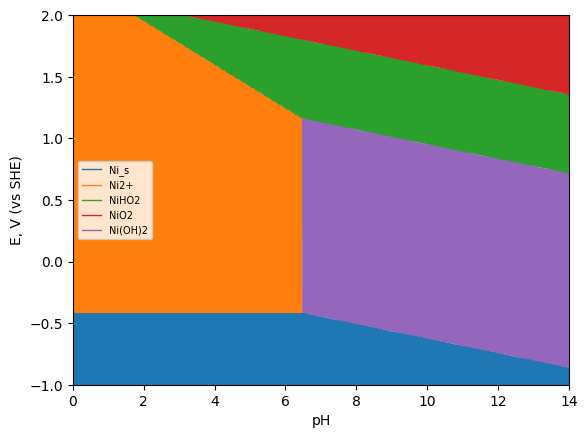

In [3]:
#Ni and water only. Based on bulk experimental thermodynamics
G_H2 = -1.16819689 # HSE06/pob + gas
G_O2 = -150.22975061 # HSE06/pob + gas
G_H2O = -76.38018759 # HSE06/pob + cpcm(water)
mu_H2O = Eh2eV*(G_H2O - G_H2 - G_O2/2)
G_Ni0 =  -1508.151934487 -1.52495808833919e-05 # HSE06/pob-mod + thermo (2x2x2 with reduced basis set) 24x24

ions = {
     "Ni2+" : (-0.478, 0, 0, 1, 2, -6), # (Eh2eV*((-1507.165817988675 - (-1507.62864315 + 1507.61184959)) - G_Ni0), 0, 0, 1, 2, -6)
     "Ni3+" : (3.745, 0, 0, 1, 3, -6),
     "NiOH+" : (-2.355, 1, 1, 1, 1, -6),
     "Ni(OH)3-": (-6.079, 3, 3, 1, -1, -6),
     "Ni(OH)4--": (-7.708, 4, 4, 1, -2, -6),
}
solids = {
     "Ni_s" : (0, 0, 0, 1, 0, 0),
    
     "Ni(OH)2":(Eh2eV*(-1659.746565139168 - G_Ni0 - G_O2 - G_H2), 2, 2, 1, 0, 0), # 24x24

     #"NiO": (Eh2eV*(-1583.377830872842 - G_Ni0 - G_O2/2), 1, 0, 1, 0, 0), # 24x24

    # "Ni3O4": (Eh2eV*(-4825.173245662815 - 3*G_Ni0 - 4*G_O2/2), 4, 0, 3, 0, 0), # 

    # "Ni2O3": (Eh2eV*(-12966.458458165649 - 8*G_Ni0 - 12*G_O2/2), 12, 0, 8, 0, 0), #

     "NiHO2":(Eh2eV*(-1659.103073599906 - 0.074/Eh2eV - G_Ni0 - G_O2 - G_H2/2), 2, 1, 1, 0, 0), # 

     "NiO2":(Eh2eV*(-1658.441432880347 - G_Ni0 - G_O2), 2, 0, 1, 0, 0), # 24x24
}
el_phases = {
    **ions,
    **solids
    }

list_of_phases = [Psi(*convert_coef(*el_phases[key], mu_H2O = mu_H2O), label=key) for key in el_phases.keys()] 

Phases = list_of_phases.copy()

for point in [(13.8, 0.807)]:
    Psis = sorted([(phase.label, phase.get_plane()(*point)) for phase in Phases], key=lambda x: x[1], reverse=True)
    print(*Psis, sep="\n")
    print()

E_min, E_max = -1.0, 2 
pH_min, pH_max = 0, 14
resolution = 400

pH_grid = np.linspace(pH_min, pH_max, resolution)
E_grid = np.linspace(E_min, E_max, resolution)

dataset = represent_PD_dataset_to_draw(
    represent_PD_dataset(
        compress_PD_dataset(
            create_PD_dataset(
                pH_grid,
                E_grid,
                Phases
                )
        )
    )
)

draw_PD_dataset(
    dataset,
    limits = {
    "xlim":(pH_min, pH_max), 
    "xlabel" : "pH", 
    "ylim": (E_min, E_max), 
    "ylabel": f"E, V (vs SHE)"
    },
    save_png=True
    )


('Ni3+', 0.9874)
('Ni_s', 0.0)
('Ni2O3', -1.993895617981552)
('Ni2+', -2.4346)
('NiOH+', -2.5423731243927237)
('Ni(OH)4--', -2.5876924975708944)
('Ni(OH)3-', -2.727919373178171)
('NiO', -4.313438143251644)
('NiO2', -4.49913062647098)
('Ni3O4', -4.521744980573994)
('Ni(OH)2', -4.8571151042973595)
('NiHO2', -4.952471070010763)



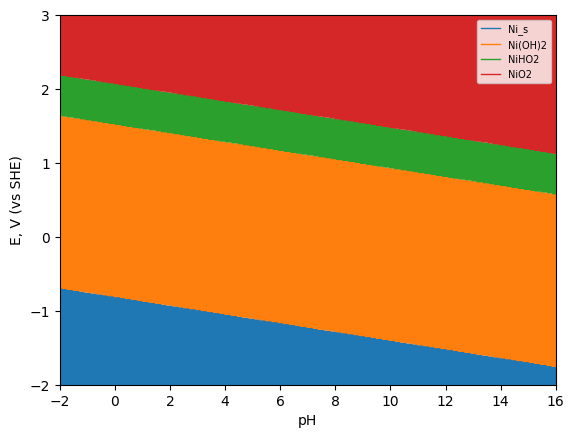

In [4]:
#Ni and water only. Based on bulk experimental thermodynamics

G_H2 = -1.172668137083 + (-1.16819689 + 1.16617571) # El-en - DLPNO-CCSD(t) + Ther-cor - HSE06 + gas
G_O2 = -150.140066193301 + (-150.22975061 + 150.21269905) # El-en - DLPNO-CCSD(t) + Ther-cor - HSE06 + gas
G_H2O = -76.351656508593 + (-76.38018759 + 76.38360608) # El-en - DLPNO-CCSD(t) + Ther-cor - HSE06 + cpcm(water)
mu_H2O = Eh2eV*(G_H2O - G_H2 - G_O2/2)
G_Ni0 = -1508.15193448# HSE06/pob-mod

ions = {
     "Ni2+" : (-0.478, 0, 0, 1, 2, -6),
     "Ni3+" : (3.745, 0, 0, 1, 3, -6),
     "NiOH+" : (-2.355, 1, 1, 1, 1, -6),
     "Ni(OH)3-": (-6.079, 3, 3, 1, -1, -6),
     "Ni(OH)4--": (-7.708, 4, 4, 1, -2, -6),
}
solids = {
     "Ni_s" : (0, 0, 0, 1, 0, 0),
    
     "Ni(OH)2":(Eh2eV*(-1659.733400401823 - G_Ni0 - G_O2 - G_H2), 2, 2, 1, 0, 0), #-1659.733400401823

     "NiO": (Eh2eV*(-1583.365182639367 - G_Ni0 - G_O2/2), 1, 0, 1, 0, 0), # -1583.365182639367

     "Ni3O4": (Eh2eV*(-4825.173245662815 - 3*G_Ni0 - 4*G_O2/2), 4, 0, 3, 0, 0), # 

     "Ni2O3": (Eh2eV*(-12966.458458165649 - 8*G_Ni0 - 12*G_O2/2), 12, 0, 8, 0, 0), # -12966.458458165649 negative freq

     "NiHO2":(Eh2eV*(-1659.090151835739 - G_Ni0 - G_O2 - G_H2/2), 2, 1, 1, 0, 0), # -1659.090151835739

     "NiO2":(Eh2eV*(-1658.426739064620 - G_Ni0 - G_O2), 2, 0, 1, 0, 0), # -1658.426739064620
}
el_phases = {
    **ions,
    **solids
    }

list_of_phases = [Psi(*convert_coef(*el_phases[key], mu_H2O = mu_H2O), label=key) for key in el_phases.keys()] 

Phases = list_of_phases.copy()

for point in [(13.8, 0.801)]:
    Psis = sorted([(phase.label, phase.get_plane()(*point)) for phase in Phases], key=lambda x: x[1], reverse=True)
    print(*Psis, sep="\n")
    print()


E_min, E_max = -2, 3
pH_min, pH_max = -2, 16
resolution = 400

pH_grid = np.linspace(pH_min, pH_max, resolution)
E_grid = np.linspace(E_min, E_max, resolution)

dataset = represent_PD_dataset_to_draw(
    represent_PD_dataset(
        compress_PD_dataset(
            create_PD_dataset(
                pH_grid,
                E_grid,
                Phases
                )
        )
    )
)

draw_PD_dataset(
    dataset,
    limits = {
    "xlim":(pH_min, pH_max), 
    "xlabel" : "pH", 
    "ylim": (E_min, E_max), 
    "ylabel": f"E, V (vs SHE)"
    },
    save_png=False
    )
